In [4]:
!pip install diptest
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from matplotlib.patches import Ellipse
from scipy.stats import gaussian_kde
from diptest import diptest
import seaborn as sns
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

## **Figure 1.1. Anomalies with Cluster Boundaries**

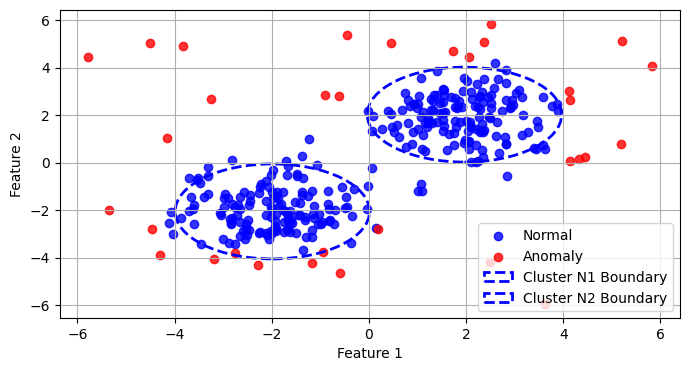

In [ ]:
np.random.seed(42)

# Cluster N1
N1 = np.random.randn(150, 2) + np.array([2, 2])
# Cluster N2
N2 = np.random.randn(150, 2) + np.array([-2, -2])

X_normal = np.vstack([N1, N2])
anomalies = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_normal, anomalies])

# True labels (for visualization only)
y_true = np.hstack([np.zeros(len(X_normal)), np.ones(len(anomalies))])
# 0 = normal, 1 = anomaly

model = IsolationForest(contamination=0.1, random_state=42).fit(X)

# Predictions (-1 = anomaly, 1 = normal)
y_pred = model.predict(X)
y_pred = np.where(y_pred == -1, 1, 0)

plt.figure(figsize=(8, 4))
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:, 1],
            c='blue', label='Normal', alpha=0.8)
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1],
            c='red', label='Anomaly', alpha=0.8)
center_N1 = np.mean(N1, axis=0)
center_N2 = np.mean(N2, axis=0)
circle_radius = 2
circle1 = plt.Circle(center_N1, circle_radius, color='blue', fill=False, linestyle='--', linewidth=2, label='Cluster N1 Boundary')
circle2 = plt.Circle(center_N2, circle_radius, color='blue', fill=False, linestyle='--', linewidth=2, label='Cluster N2 Boundary')

plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)

plt.title("Anomaly Detection using Isolation Forest with Cluster Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## **Figure 1.2. Learned decision boundary for anomaly detection**

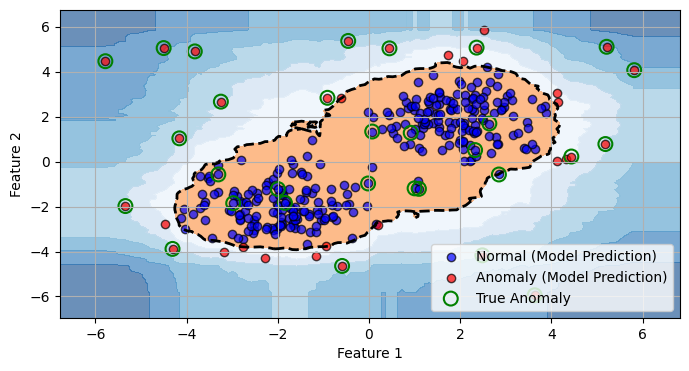

In [ ]:
# Meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                           np.arange(y_min, y_max, 0.1))

# Predict anomaly scores for each point in the meshgrid
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 4))

# Plot the decision boundary and anomaly scores as contours
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.Blues_r, alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black', linestyles='--') # Decision boundary
plt.contourf(xx, yy, Z, levels=[0, Z.max()], cmap=plt.cm.Oranges_r, alpha=0.6)

# Plot the actual data points
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:, 1],
            c='blue', label='Normal (Model Prediction)', alpha=0.7, edgecolors='k')
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1],
            c='red', label='Anomaly (Model Prediction)', alpha=0.7, edgecolors='k')

# Overlay the true anomalies (for comparison)
plt.scatter(anomalies[:, 0], anomalies[:, 1], s=100, facecolors='none', edgecolors='green', label='True Anomaly', linewidth=1.5)

plt.title("Isolation Forest Decision Boundary and Anomaly Scores")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## **Figure 1.4. Mapping Probability Density P(x) to Anomaly Score -log P(x)**

<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_4591/1351175543.py:25: SyntaxWarning: invalid escape sequence '\g'
  line3 = ax2.axhline(threshold_val, color='red', linestyle=':', linewidth=1.5, label='Risk Threshold ($\gamma$)')


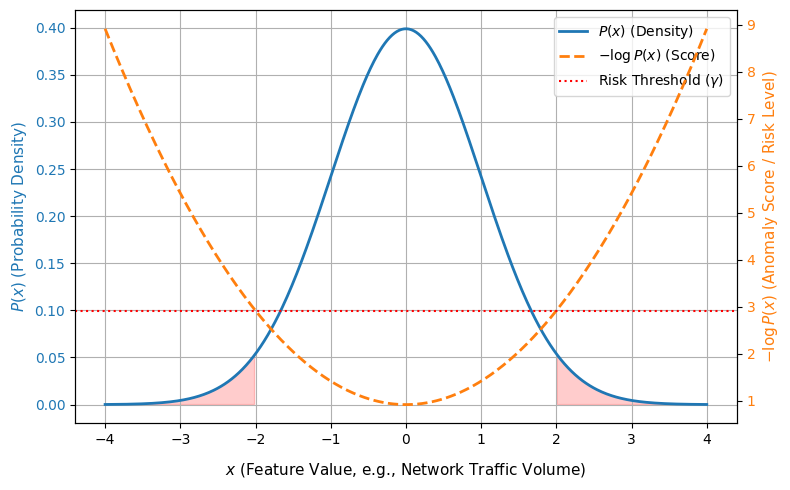

In [ ]:
x = np.linspace(-4, 4, 500)

# Standard normal distribution formula: P(x)
p_x = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)
# Negative log-likelihood formula: -log P(x)
nll = -np.log(p_x)

fig, ax1 = plt.subplots(figsize=(8, 5))

color_blue = '#1f77b4'
ax1.set_xlabel('$x$ (Feature Value, e.g., Network Traffic Volume)', fontsize=11, labelpad=10)
ax1.set_ylabel('$P(x)$ (Probability Density)', color=color_blue, fontsize=11)
line1 = ax1.plot(x, p_x, color=color_blue, linewidth=2, label='$P(x)$ (Density)')
ax1.tick_params(axis='y', labelcolor=color_blue)

ax1.fill_between(x, p_x, where=(x > 2) | (x < -2), color='red', alpha=0.2, label='Anomalous Regions')

ax2 = ax1.twinx()
color_orange = '#ff7f0e'
ax2.set_ylabel('$-\\log P(x)$ (Anomaly Score / Risk Level)', color=color_orange, fontsize=11)
line2 = ax2.plot(x, nll, color=color_orange, linewidth=2, linestyle='--', label='$-\\log P(x)$ (Score)')
ax2.tick_params(axis='y', labelcolor=color_orange)

threshold_val = -np.log((1 / np.sqrt(2 * np.pi)) * np.exp(-2**2 / 2))
line3 = ax2.axhline(threshold_val, color='red', linestyle=':', linewidth=1.5, label='Risk Threshold ($\gamma$)')

lines = line1 + line2 + [line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

ax1.grid()
fig.tight_layout()
plt.show()


# **Figure 1.6: Box Plot of Feature 1 in Dataset X with IQR**

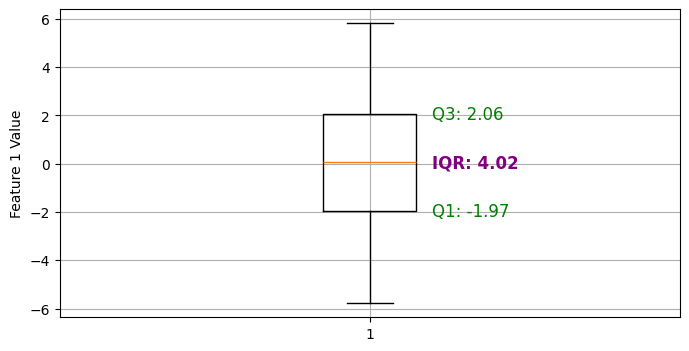

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(X[:, 0])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(X[:, 0], 25)
Q3 = np.percentile(X[:, 0], 75)
IQR = Q3 - Q1

# Add annotations for Q1, Q3, and IQR
plt.text(1.1, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='green', fontsize=12)
plt.text(1.1, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=12)
plt.text(1.1, Q1 + IQR/2, f'IQR: {IQR:.2f}', verticalalignment='center', color='purple', fontsize=12, fontweight='bold')
plt.ylabel('Feature 1 Value')
plt.grid(True)
plt.show()

## **Figure 1.7: Multivariate anomaly detection using Mahalanobis distance**

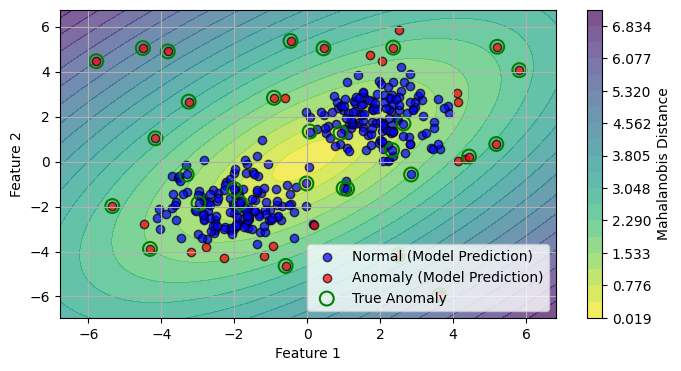

In [ ]:
# Mean of the dataset X
mean_X = np.mean(X, axis=0)

# Calculate the covariance matrix of X
cov_X = np.cov(X, rowvar=False)

# Calculate the inverse of the covariance matrix
inv_cov_X = np.linalg.inv(cov_X)

# Function to calculate Mahalanobis distance for a single point
def mahalanobis_distance(point, mean, inv_cov):
    diff = point - mean
    return np.sqrt(diff.reshape(1, -1) @ inv_cov @ diff.reshape(-1, 1))[0, 0]

# Calculate Mahalanobis distance for all points in X
mahalanobis_distances = np.array([mahalanobis_distance(p, mean_X, inv_cov_X) for p in X])

# Create a meshgrid for the contour plot
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                           np.arange(y_min, y_max, 0.1))

# Calculate Mahalanobis distance for each point in the meshgrid
Z_mahalanobis = np.array([mahalanobis_distance(np.array([x, y]), mean_X, inv_cov_X) for x, y in zip(xx.ravel(), yy.ravel())])
Z_mahalanobis = Z_mahalanobis.reshape(xx.shape)

plt.figure(figsize=(8, 4))

# Plot the Mahalanobis distance contours
contour = plt.contourf(xx, yy, Z_mahalanobis, levels=np.linspace(Z_mahalanobis.min(), Z_mahalanobis.max(), 20), cmap='viridis_r', alpha=0.7)
plt.colorbar(contour, label='Mahalanobis Distance')

# Plot the actual data points
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:, 1], c='blue', label='Normal (Model Prediction)', alpha=0.7, edgecolors='k')
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1], c='red', label='Anomaly (Model Prediction)', alpha=0.7, edgecolors='k')

# Overlay the true anomalies (for comparison)
plt.scatter(anomalies[:, 0], anomalies[:, 1], s=100, facecolors='none', edgecolors='green', label='True Anomaly', linewidth=1.5)

plt.title('Mahalanobis Distance Contours and Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## **Figure 1.8: Histogram and Kernel Density Estimate**

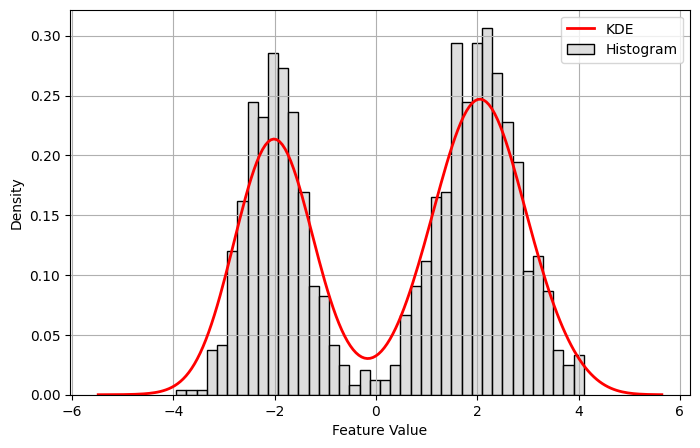

Dip Statistic : 0.0825
P-value       : 0.0000
Evidence of multimodality detected.


In [13]:
np.random.seed(42)
data = np.concatenate([
    np.random.normal(-2, 0.6, 500),
    np.random.normal(2, 0.8, 700)])

plt.figure(figsize=(8,5))

sns.histplot(
    data,
    bins=40,
    stat='density',
    color='lightgray',
    edgecolor='black',
    label='Histogram')

sns.kdeplot(
    data,
    color='red',
    linewidth=2,
    label='KDE')

plt.xlabel("Feature Value")
plt.ylabel("Density")
# plt.title("Histogram and Kernel Density Estimate")
plt.legend()
plt.grid()
plt.show()

dip, p_value = diptest(data)
print(f"Dip Statistic : {dip:.4f}")
print(f"P-value       : {p_value:.4f}")
if p_value < 0.05:
    print("Evidence of multimodality detected.")
else:
    print("No evidence of multimodality.")

## **Figure 1.9: Model Selection Using Bayesian Information Criterion**

Optimal Components: 2


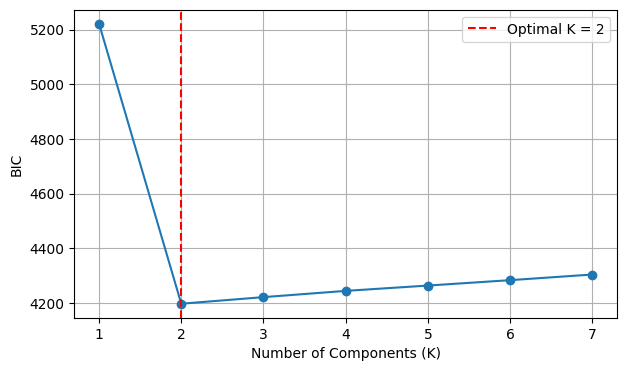

In [18]:
X = data.reshape(-1,1)
bic_scores = []
k_values = range(1,8)

for k in k_values:
    model = GaussianMixture(
        n_components=k,
        random_state=42)

    model.fit(X)

    bic_scores.append(model.bic(X))

best_k = k_values[np.argmin(bic_scores)]
print("Optimal Components:", best_k)

plt.figure(figsize=(7,4))
plt.plot(
    k_values,
    bic_scores,
    marker='o')
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC")
# plt.title("Model Selection Using Bayesian Information Criterion")
plt.grid()
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal K = {best_k}')
plt.legend()
plt.show()

## **Figure 1.10: Finite Mixture Model Fit**

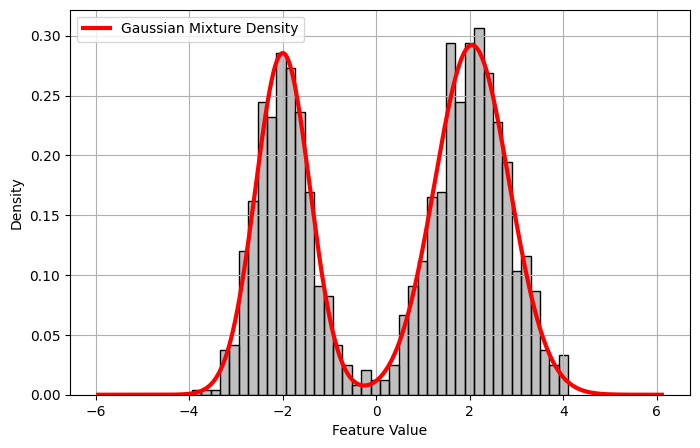

In [20]:
best_gmm = GaussianMixture(
    n_components=best_k,
    random_state=42)

best_gmm.fit(X)

x_vals = np.linspace(
    data.min()-2,
    data.max()+2,
    1000)

pdf = np.exp(
    best_gmm.score_samples(
        x_vals.reshape(-1,1)))

plt.figure(figsize=(8,5))
sns.histplot(
    data,
    bins=40,
    stat='density',
    alpha=0.5,
    color='gray')

plt.plot(
    x_vals,
    pdf,
    color='red',
    linewidth=3,
    label='Gaussian Mixture Density')

plt.xlabel("Feature Value")
plt.ylabel("Density")
# plt.title("Finite Mixture Model Fit")
plt.legend()
plt.grid()
plt.show()

## **Figure 1.11: Anomaly Score Distribution Based on Negative Log-Likelihood**

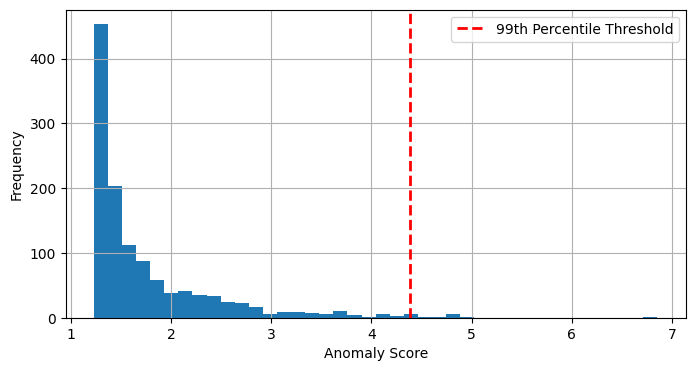

In [24]:
scores = -best_gmm.score_samples(X)

threshold = np.percentile(
    scores,
    99)

anomaly_flags = scores > threshold
plt.figure(figsize=(8,4))
plt.hist(
    scores,
    bins=40)

plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='99th Percentile Threshold')

plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
# plt.title("Anomaly Score Distribution")
plt.legend()
plt.grid()
plt.show()

## **Figure 2.1. Point Anomalies**

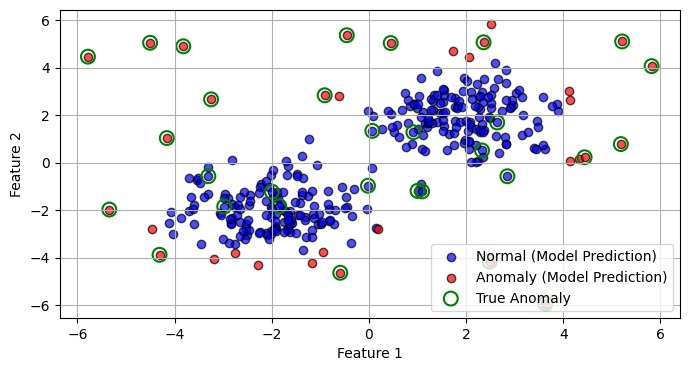

In [ ]:
plt.figure(figsize=(8, 4))

# Plot normal points
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:, 1],
            c='blue', label='Normal (Model Prediction)', alpha=0.7, edgecolors='k')

# Plot points predicted as anomalies by the model
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1],
            c='red', label='Anomaly (Model Prediction)', alpha=0.7, edgecolors='k')

plt.scatter(anomalies[:, 0], anomalies[:, 1], s=100, facecolors='none', edgecolors='green', label='True Anomaly', linewidth=1.5)

plt.title('Point Anomalies: Isolation Forest Predictions vs. True Anomalies')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## **Figure 2.2. Subtle overlap classes: The challenge (a) anomalies are rare and lie far from normal region → easy to detect, (b) anomalies overlap with normal instances → hard to detect**

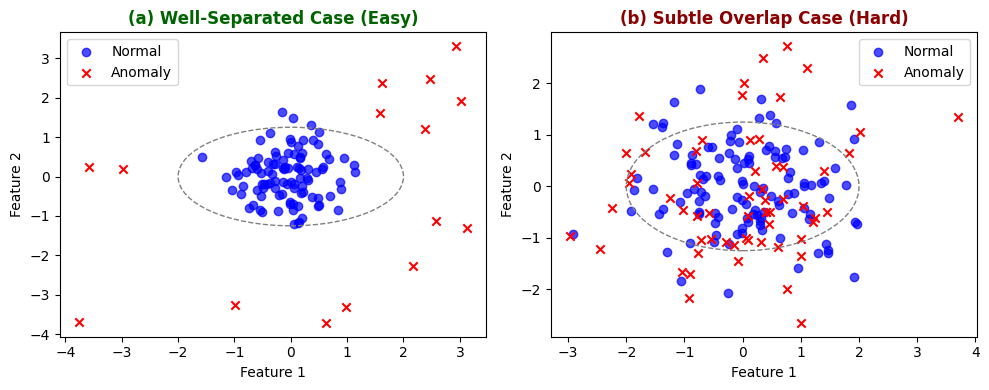

In [ ]:
np.random.seed(42)

def generate_easy_case():
    normal = np.random.randn(100, 2) * 0.6

    # Anomalies far away
    anomaly = np.random.uniform(low=-4, high=4, size=(20, 2))
    anomaly = anomaly[np.linalg.norm(anomaly, axis=1) > 2]

    return normal, anomaly


def generate_hard_case():
    normal = np.random.randn(120, 2) * 0.9
    # Overlapping anomalies
    anomaly = np.random.randn(60, 2) * 1.2
    return normal, anomaly

def plot_case(ax, normal, anomaly, title, description, color):
    ax.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal', alpha=0.7)
    ax.scatter(anomaly[:, 0], anomaly[:, 1], c='red', marker='x', label='Anomaly')

    ellipse = Ellipse((0, 0), width=4, height=2.5,
                      edgecolor='gray', facecolor='none',
                      linestyle='--')
    ax.add_patch(ellipse)

    ax.set_title(title, color=color, fontsize=12, fontweight='bold')
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    ax.text(0, -3.5, description,
            ha='center', fontsize=10, wrap=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

normal_easy, anomaly_easy = generate_easy_case()
plot_case(
    axes[0],
    normal_easy,
    anomaly_easy,
    "(a) Well-Separated Case (Easy)",
    "",
    'darkgreen')

normal_hard, anomaly_hard = generate_hard_case()
plot_case(
    axes[1],
    normal_hard,
    anomaly_hard,
    "(b) Subtle Overlap Case (Hard)",
    "",
    'darkred')

plt.tight_layout()
plt.show()

## **Figure 2.3. Challenges posed by subtle anomalies across four categories of anomaly detection techniques**

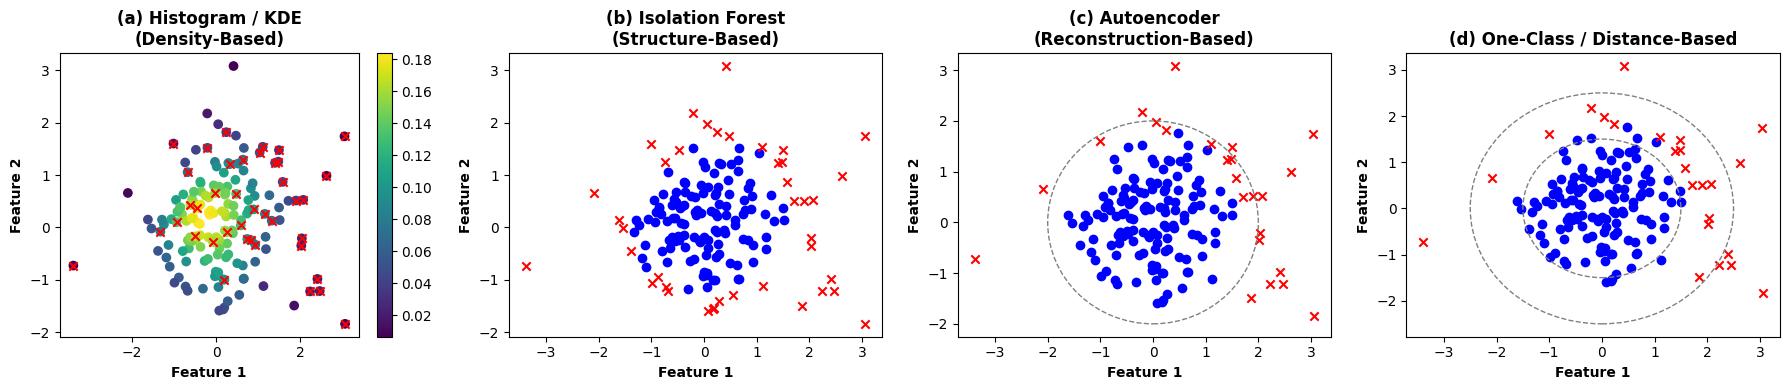

In [ ]:
np.random.seed(42)
normal = np.random.randn(120, 2) * 0.8
anomaly = np.random.randn(40, 2) * 1.2 + 0.5

X = np.vstack([normal, anomaly])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

ax = axes[0]
# KDE density
xy = np.vstack([X[:, 0], X[:, 1]])
density = gaussian_kde(xy)(xy)

sc = ax.scatter(X[:, 0], X[:, 1], c=density, cmap='viridis')
ax.scatter(anomaly[:, 0], anomaly[:, 1], color='red', marker='x')
plt.colorbar(sc, ax=ax)
ax.set_title("(a) Histogram / KDE\n(Density-Based)", fontweight='bold')
ax.set_xlabel("Feature 1", fontweight='bold')
ax.set_ylabel("Feature 2", fontweight='bold')
ax.text(0, -3,
        "",
        ha='center', fontsize=10)


ax = axes[1]
iso = IsolationForest(contamination=0.25, random_state=42)
iso.fit(X)
pred = iso.predict(X)

ax.scatter(X[pred == 1, 0], X[pred == 1, 1], c='blue')
ax.scatter(X[pred == -1, 0], X[pred == -1, 1], c='red', marker='x')
ax.set_title("(b) Isolation Forest\n(Structure-Based)", fontweight='bold')
ax.set_xlabel("Feature 1", fontweight='bold')
ax.set_ylabel("Feature 2", fontweight='bold')
ax.text(0, -3,
        "",
        ha='center', fontsize=10)

ax = axes[2]
# reconstruction error (distance from center)
center = np.mean(normal, axis=0)
recon_error = np.linalg.norm(X - center, axis=1)
# Threshold (simulate reconstruction)
threshold = np.percentile(recon_error, 85)

ax.scatter(X[recon_error <= threshold, 0],
           X[recon_error <= threshold, 1], c='blue')
ax.scatter(X[recon_error > threshold, 0],
           X[recon_error > threshold, 1], c='red', marker='x')

circle = plt.Circle((0, 0), 2, fill=False, linestyle='--', color='gray')
ax.add_patch(circle)
ax.set_title("(c) Autoencoder\n(Reconstruction-Based)", fontweight='bold')
ax.set_xlabel("Feature 1", fontweight='bold')
ax.set_ylabel("Feature 2", fontweight='bold')
ax.text(0, -3,
        "",
        ha='center', fontsize=10)

ax = axes[3]
# Distance from center
dist = np.linalg.norm(X - center, axis=1)
# Boundary
threshold = np.percentile(dist, 85)

ax.scatter(X[dist <= threshold, 0],
           X[dist <= threshold, 1], c='blue')
ax.scatter(X[dist > threshold, 0],
           X[dist > threshold, 1], c='red', marker='x')

for r in [1.5, 2.5]:
    circle = plt.Circle((0, 0), r, fill=False, linestyle='--', color='gray')
    ax.add_patch(circle)

ax.set_title("(d) One-Class / Distance-Based", fontweight='bold')
ax.set_xlabel("Feature 1", fontweight='bold')
ax.set_ylabel("Feature 2", fontweight='bold')
ax.text(0, -3,
        "",
        ha='center', fontsize=10)

plt.tight_layout()
plt.show()
